In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import peak_local_max

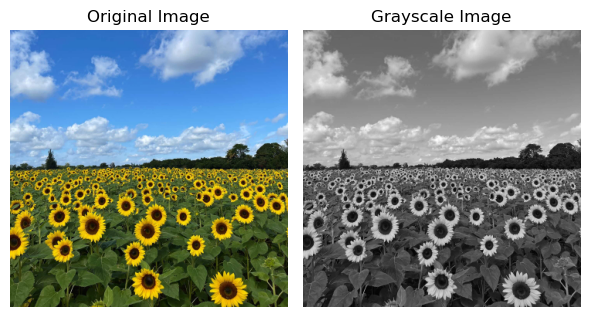

In [5]:
im = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
im_gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

fig, axs = plt.subplots(1, 2, figsize=(6, 6))
axs[0].imshow(im_rgb)
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(im_gray, cmap='gray')
axs[1].set_title('Grayscale Image')
axs[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
h, w = im_gray.shape
sigmas = np.arange(1,11,1)

scale_space = np.empty((h, w, len(sigmas)), dtype=np.float32)
for i, sigma in enumerate(sigmas):
    log_hw = 3 * sigma
    X, Y = np.meshgrid(np.arange(-log_hw, log_hw + 1, 1), np.arange(-log_hw, log_hw + 1, 1))
    log = 1/(2*np.pi*sigma**2)*(X**2/(sigma**2) + Y**2/(sigma**2) - 2)*np.exp(-(X**2 + Y**2)/(2*sigma**2))
    f_log = cv.filter2D(im_gray, -1, log)
    scale_space[:, :, i] = f_log
local_maxima_coords = peak_local_max(scale_space, footprint=np.ones((3, 3, len(sigmas))), threshold_rel=0.7)

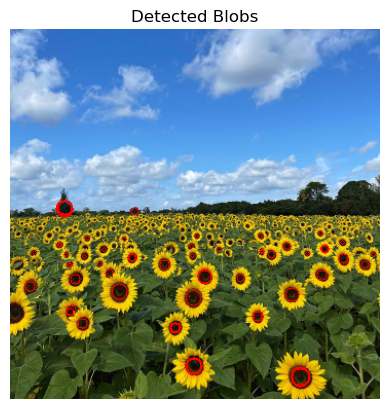

Max radius is: 9
Max circle in: (282, 337)


In [99]:
# plot circles on original image
max_radius = 0
max_cood = tuple()
im_with_circles = im_rgb.copy()
for coord in local_maxima_coords:
    y, x, sigma_idx = coord
    sigma = sigmas[sigma_idx]
    radius = int(np.sqrt(2) * sigma)
    if radius > max_radius:
        max_radius = radius
        max_cood = (x, y)
    cv.circle(im_with_circles, (x, y), radius, (255, 0, 0), 1)
plt.imshow(im_with_circles)
plt.axis('off')
plt.title('Detected Blobs')
plt.show()

print(f"Max radius is: {max_radius}")
print(f"Max circle in: {max_cood}")